# Assignment 6: RNN Implementation
-------------------
**Dr. Dave Wanik - University of Connecticut**
A weather-based energy forecasting homework.

* **Your Name Here: George Khramtchenko**
* **Your NetID Here: ftg25004**

Energy demand forecasting as a function of weather data is an extremely interesting and relevant topic.

I've given you a curated (mostly?) clean dataset that you can use to predict `df['Demand']` as a function of the weather variables.

Of course, you cannot use the df[`Datetime`] column directly into the model - but you can feature engineer the column to make features temporal features for modeling like Julian day of year (0-365), week of year, and number of years since 2012.

**Sorting: (5 pts)**
Sort the data from oldest to newest.

**Cleaning: (10 pts)**
Describe and impute (or drop) the missing values using an appropriate method. At this time, you are welcome to perform feature engineering (optional).

**Process as a 3D tensor: (10 pts)**
Process the data as a 3D tensor with a lookback of your choice (use a value greater than or equal to 12).

**Model Architecure: (10 pts)**
You must use a model with:
* at least two recurrent layers
* at least one convolution layer
* dropout (recurrent or between Dense layers)
* appropriate activation functions

**Experiments: (15 pts each, 30 pts total)**
Freeze the model architecutre and perform a *walk-forward validation* where:
* the first 50k samples predict the remaining ~46k samples
* the first 80k samples predict the remaining ~16k samples

Walk-forward validation is very common to use on the job - it shows how your model (ideally) gets better over time as it gets more data to use. Use subheads

**Evaluation (15 points each, 30 pts total)**
Evaluate your model for each of these experiments - hopefully, your model should improve as you give it more data to use! But that depends on your choice of architecture. You should have:
* quantitative error metrics (mean absolute error and others)
* scatterplots of actual vs. predicted
* time series plots of actual vs. predicted

You should also compare to baseline model like persistence (assume today's energy usage is the same as yesterday's - requires you to shift by 24... ask on discussion board if questions!) or ignore the sequence data and treat this as a 2D problem (a regular supervised learning problem!)

**Conclusions (5 pts total)**
* What did you learn from this assignment? Did your walk-forward validation work as you expected it to?
* What else would you do differently next time?
* At least five great bullets please.

In [35]:
# https://drive.google.com/file/d/1jdTV2Fwcnv0Sxl3v2hSkdupJaaLvDOIZ/view?usp=sharing
!gdown 1jdTV2Fwcnv0Sxl3v2hSkdupJaaLvDOIZ

Downloading...
From: https://drive.google.com/uc?id=1jdTV2Fwcnv0Sxl3v2hSkdupJaaLvDOIZ
To: /content/BDL_cleanweather_energy (1).csv
100% 7.38M/7.38M [00:00<00:00, 33.7MB/s]


In [36]:
import pandas as pd
df = pd.read_csv('BDL_cleanweather_energy (1).csv')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96427 entries, 0 to 96426
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  96427 non-null  object 
 1   Demand    96427 non-null  float64
 2   BDL_tmpf  96160 non-null  float64
 3   BDL_dwpf  96160 non-null  float64
 4   BDL_relh  96160 non-null  float64
 5   BDL_drct  96160 non-null  float64
 6   BDL_sknt  96160 non-null  float64
 7   BDL_p01i  96160 non-null  float64
 8   BDL_alti  96160 non-null  float64
 9   BDL_mslp  96160 non-null  float64
 10  BDL_vsby  96160 non-null  float64
dtypes: float64(10), object(1)
memory usage: 8.1+ MB


**Prompt 1:** Sort the data from oldest to newest.

In [38]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

Extract the temporal features according to the instructions: Julian day of year (0-365), week of year, and number of years since 2012.

In [39]:
df['JulianDay'] = df['Datetime'].dt.dayofyear
df['WeekOfYear'] = df['Datetime'].dt.isocalendar().week.astype(int)
df['YearsSince2012'] = df['Datetime'].dt.year - 2012

# Display sorted data from oldest to newest
display(df.head())

,Datetime,Demand,BDL_tmpf,BDL_dwpf,BDL_relh,BDL_drct,BDL_sknt,BDL_p01i,BDL_alti,BDL_mslp,BDL_vsby,JulianDay,WeekOfYear,YearsSince2012
0,2019-01-01 00:00:00,2713.617,37.9,37.9,100.0,360.0,4.0,0.0700,29.88,1009.7,5.0,1,1,7
1,2019-01-01 01:00:00,2578.343,37.9,37.9,100.0,360.0,4.0,0.1100,29.79,1006.3,2.0,1,1,7
2,2019-01-01 02:00:00,2467.969,37.9,37.9,100.0,340.0,7.0,0.0100,29.70,1003.3,2.0,1,1,7
3,2019-01-01 03:00:00,2397.140,37.9,37.9,100.0,310.0,6.0,0.0100,29.63,1002.3,1.5,1,1,7
4,2019-01-01 04:00:00,2381.258,37.9,37.9,100.0,140.0,3.0,0.0001,29.58,1001.2,1.5,1,1,7


**Prompt 2:** Describe and impute (or drop) the missing values using an appropriate method. At this time, you are welcome to perform feature engineering (optional).

Check for missing values across all columns.

In [40]:
mv = df.isnull().sum()
print("Missing values before dropping:\n", mv[mv > 0])

Missing values before dropping:
 BDL_tmpf    267
BDL_dwpf    267
BDL_relh    267
BDL_drct    267
BDL_sknt    267
BDL_p01i    267
BDL_alti    267
BDL_mslp    267
BDL_vsby    267
dtype: int64


Drop the missing value rows (267) for simplicity for these columns.

In [41]:
df.dropna(inplace=True)
print("Missing values after dropping:\n", df.isnull().sum().sum())
df.info()

Missing values after dropping:
 0
<class 'pandas.core.frame.DataFrame'>
Index: 96160 entries, 0 to 96426
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Datetime        96160 non-null  datetime64[ns]
 1   Demand          96160 non-null  float64       
 2   BDL_tmpf        96160 non-null  float64       
 3   BDL_dwpf        96160 non-null  float64       
 4   BDL_relh        96160 non-null  float64       
 5   BDL_drct        96160 non-null  float64       
 6   BDL_sknt        96160 non-null  float64       
 7   BDL_p01i        96160 non-null  float64       
 8   BDL_alti        96160 non-null  float64       
 9   BDL_mslp        96160 non-null  float64       
 10  BDL_vsby        96160 non-null  float64       
 11  JulianDay       96160 non-null  int32         
 12  WeekOfYear      96160 non-null  int64         
 13  YearsSince2012  96160 non-null  int32         
dtypes: datetime64[ns](1), flo

**Prompt 3:** Process the data as a 3D tensor with a lookback of your choice (use a value greater than or equal to 12).

Select the features for model use, including the newly engineered temporal features.

In [42]:
features = ['Demand', 'BDL_tmpf', 'BDL_dwpf', 'BDL_relh', 'BDL_drct', 'BDL_sknt', 'BDL_p01i', 'BDL_alti', 'BDL_mslp', 'BDL_vsby', 'JulianDay', 'WeekOfYear', 'YearsSince2012']
data = df[features].values

Normalize the features using `MinMaxScaler` to scale between 0 and 1, as is customary for neural networks.

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Create the 3D tensor, or sequences, using a lookback of **24**. This will result in each sample consisting of the 24 previous time steps to predict the next time step's demand.

In [44]:
import numpy as np

lookback = 24
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, lookback)

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (96136, 24, 13)
Shape of y (target): (96136,)


Store the scaler for the `Demand` column for future evaluation use. Additionally, store the scaler for the entire feature set for future use.

In [45]:
demand_scaler = MinMaxScaler()
demand_scaler.fit(df[['Demand']])
full_features_scaler = scaler

**Prompt 4:** Use a model with:
* at least two recurrent layers
* at least one convolution layer
* dropout (recurrent or between Dense layers)
* appropriate activation functions

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, Dense, Dropout, Flatten

# Define a Sequential model with relu activation, a Conv1D,and two LTSM layers
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    LSTM(100, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# Compile and print model summary
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 22, 64)         │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 22, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 22, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,811 (385.98 KB)

 Trainable params: 98,811 (385.98 KB)

 Non-trainable params: 0 (0.00 B)

**Prompt 5:** Freeze the model architecutre and perform a *walk-forward validation* where:
* the first 50k samples predict the remaining ~46k samples
* the first 80k samples predict the remaining ~16k samples

In [47]:
def walk_forward_validation(X, y, initial_train_size, model_architecture, epochs=50, batch_size=32, verbose=0):
    predictions = []
    actuals = []
    models = []

    # Determine  number of steps for walk-forward validation via if-elif statement
    if initial_train_size == 50000:
        train_end_idx = initial_train_size
    elif initial_train_size == 80000:
        train_end_idx = initial_train_size
    else:
        raise ValueError("Invalid initial_train_size detected. Must be 50000 or 80000.")

    # Split data
    X_train = X[:train_end_idx]
    y_train = y[:train_end_idx]
    X_test = X[train_end_idx:]
    y_test = y[train_end_idx:]

    # Print confirmation for number of train and test samples
    # print(f"Training with {len(X_train)} samples, testing with {len(X_test)} samples.")

    # Perform model archuitecture cloning to obtain a fresh model for each experiment wuth same initial weights
    new_model = model_architecture

    # Train the model
    history = new_model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        shuffle=False
    )
    models.append(new_model)

    # Make predictions
    y_pred = new_model.predict(X_test)
    predictions.extend(y_pred.flatten())
    actuals.extend(y_test.flatten())

    # Return results
    return np.array(actuals), np.array(predictions), models, history

Run experiment one (50,000 samples), followed by experiment two (80,000 samples).

In [48]:
# Experiment 1: First 50k samples
print("\nExperiment 1 (initial_train_size=50,000)")
actuals_50k, predictions_50k, models_50k, history_50k = walk_forward_validation(X, y, 50000, model, epochs=5, verbose=1)

# Experiment 2: First 80k samples with re-initialized model with fresh weights
model_2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    LSTM(100, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_2.compile(optimizer='adam', loss='mse')

print("\nExperiment 2 (initial_train_size=80,000)")
actuals_80k, predictions_80k, models_80k, history_80k = walk_forward_validation(X, y, 80000, model_2, epochs=5, verbose=1)

print("Walk-forward validation experiments completed.")


Experiment 1 (initial_train_size=50,000)
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - loss: 0.0089
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - loss: 0.0028
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - loss: 0.0013
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - loss: 8.5645e-04
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - loss: 7.5826e-04
1442/1442 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step

Experiment 2 (initial_train_size=80,000)
Epoch 1/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - loss: 0.0059
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 70s 28ms/step - loss: 0.0016
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - loss: 9.5261e-04
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - loss: 7.2137e-04
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 70s 28ms/step - loss: 6.1621e-04
505/505 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
Walk-forward validation experiments completed.


**Prompt 6:** Evaluate your model for each of these experiments - hopefully, your model should improve as you give it more data to use! But that depends on your choice of architecture. You should have:
* quantitative error metrics (mean absolute error and others)
* scatterplots of actual vs. predicted
* time series plots of actual vs. predicted


Evaluation for Experiment 1 (50k Train) ---
Mean Absolute Error (MAE): 144.21
Mean Squared Error (MSE): 37269.57
Root Mean Squared Error (RMSE): 193.05



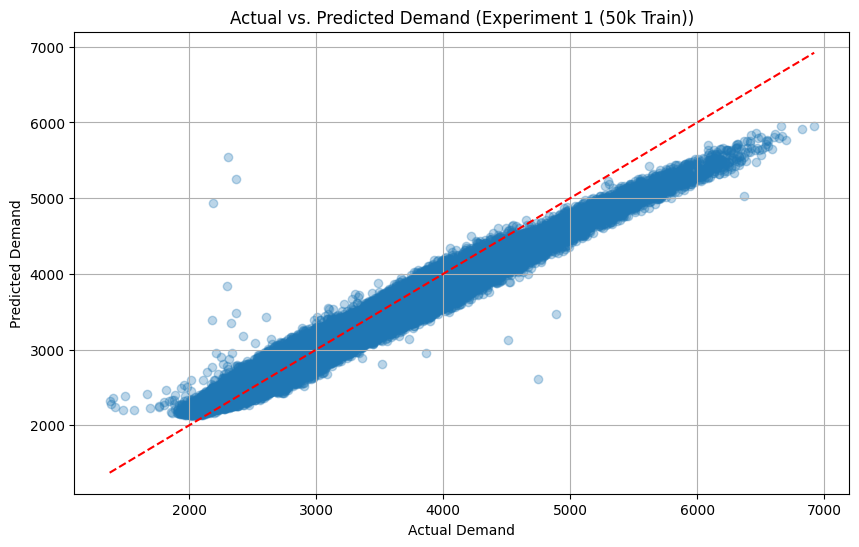

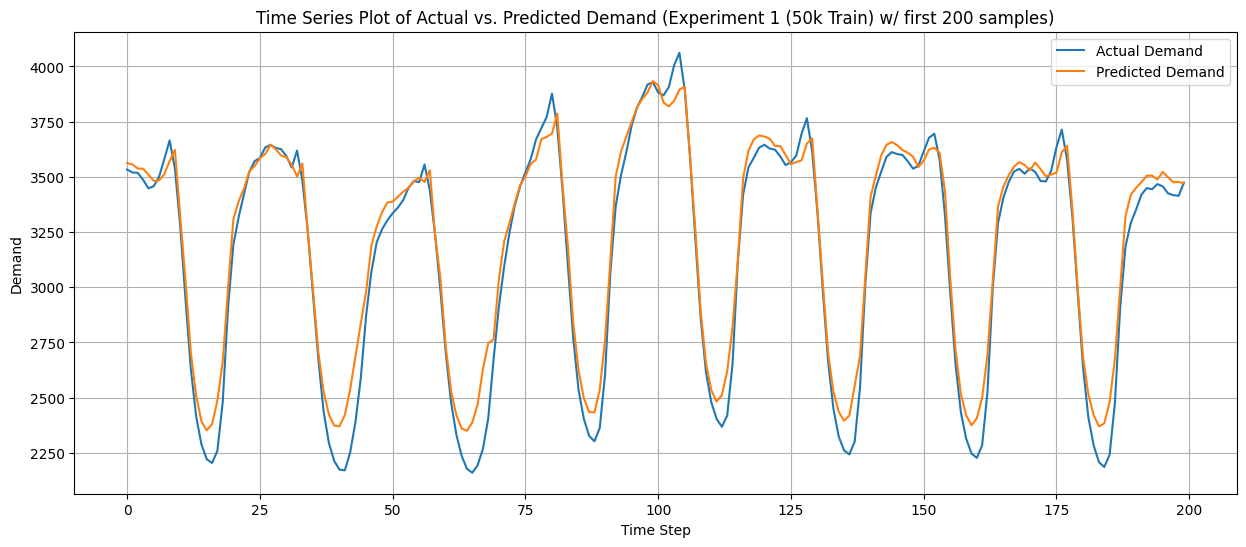


Evaluation for Experiment 2 (80k Train) ---
Mean Absolute Error (MAE): 161.32
Mean Squared Error (MSE): 36525.84
Root Mean Squared Error (RMSE): 191.12



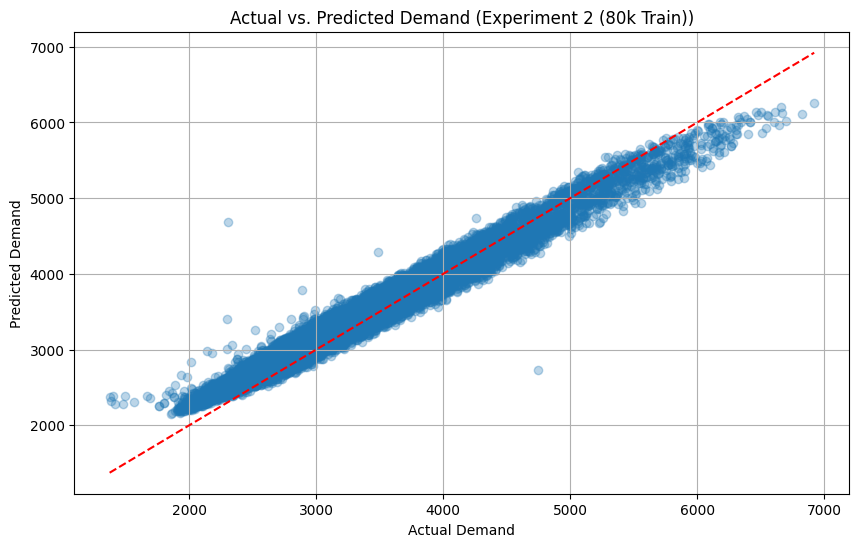

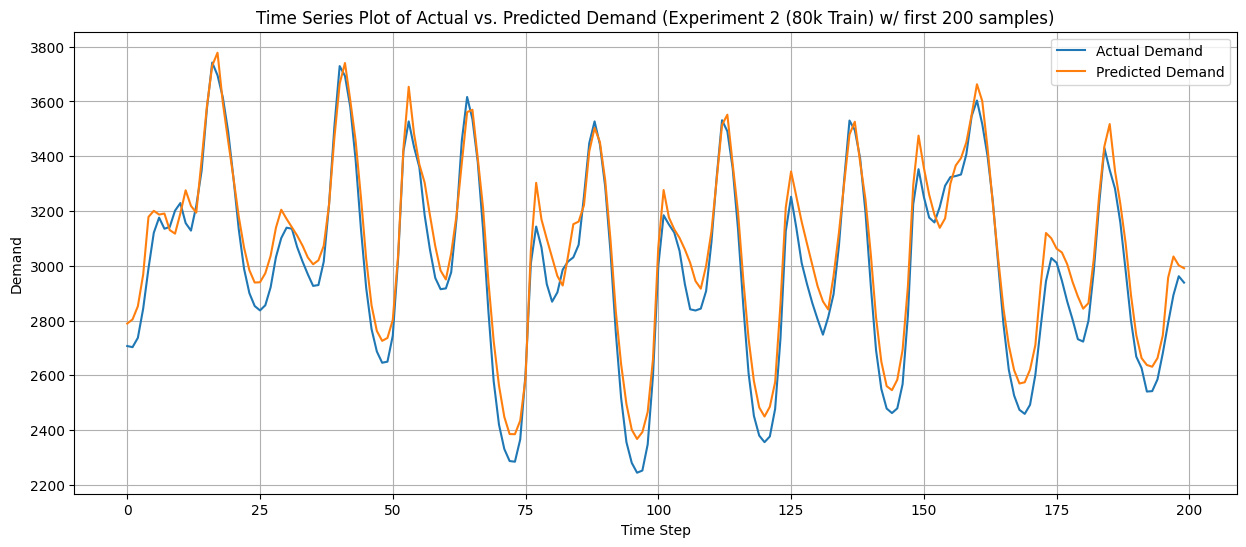

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(actuals_scaled, predictions_scaled, demand_scaler, experiment_name):
    # Perform inverse transformation to the original scale
    actuals_original = demand_scaler.inverse_transform(actuals_scaled.reshape(-1, 1)).flatten()
    predictions_original = demand_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

    # Perform quantitative error metric calculations
    mae = mean_absolute_error(actuals_original, predictions_original)
    mse = mean_squared_error(actuals_original, predictions_original)
    rmse = np.sqrt(mse)

    print(f"\nEvaluation for {experiment_name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}\n")

    # Scatterplot of Actual vs. Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals_original, predictions_original, alpha=0.3)
    plt.plot([min(actuals_original), max(actuals_original)], [min(actuals_original), max(actuals_original)], 'r--')
    plt.title(f'Actual vs. Predicted Demand ({experiment_name})')
    plt.xlabel('Actual Demand')
    plt.ylabel('Predicted Demand')
    plt.grid(True)
    plt.show()

    # Time Series Plot of Actual vs. Predicted (first 200 samples for better visibility)
    plt.figure(figsize=(15, 6))
    plt.plot(actuals_original[:200], label='Actual Demand')
    plt.plot(predictions_original[:200], label='Predicted Demand')
    plt.title(f'Time Series Plot of Actual vs. Predicted Demand ({experiment_name} w/ first 200 samples)')
    plt.xlabel('Time Step')
    plt.ylabel('Demand')
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluate Experiment 1 (50k samples training)
evaluate_model(actuals_50k, predictions_50k, demand_scaler, "Experiment 1 (50k Train)")

# Evaluate Experiment 2 (80k samples training)
evaluate_model(actuals_80k, predictions_80k, demand_scaler, "Experiment 2 (80k Train)")

**Prompt 7:** What did you learn from this assignment? Did your walk-forward validation work as you expected it to?
What else would you do differently next time?
At least five great bullets please.

### What did you learn from this assignment? Did your walk-forward validation work as you expected it to?

* I learned how to build and evaluate a time series forecasting model with recurrent and convolutional layers, such as LTSM. Performing feature engineering, transforming the `Datetime` column into `JulianDay`, `WeekOfYear`, and `YearsSince2012` was necessary for providing temporal context to the model, along with normalizing the data for optimal neural network training.

* Interestingly, the walk-forward validation did not work as I had expected it would initially. I believed that training the model with a larger dataset of 80,000 samples would lead to better model performance compared to training it with a smaller dataset of only 50,000 samples. Instead, when the model was trained on 80,000 samples higher error metrics (MAE, MSE, RMSE) were observed for its testing set.

### What else would you do differently next time?
*   **Hyperparameter Tuning:** I would perform hyperparameter tuning for each walk-forward validation split independently, or at least validate on a hold-out set within each training window to find the optimal number of epochs, as I suspect that the current fixed 5 epochs might not be most appropriate for both scenarios.
*   **Comparison to Baseline Models:** Include a comparison against a simple persistence model (e.g., today's demand is yesterday's demand shifted by 24 hours) to better contextualize the performance of the deep learning model.
*   **Different Model Architectures:** It would be worth exploring other recurrent layers like GRUs, or deeper Conv1D stacks to see if a different architecture may be better suited for this specific dataset.
*   **Error Analysis:** Conduct an in-depth error analysis by looking for patterns in where the model performs poorly (specific times of day, seasons, extreme weather conditions), and use this to for further feature engineering or other model refining.